In [14]:
# Instalação dos pacotes no ambiente
!pip install datasets scikit-learn nltk seaborn matplotlib -q

# Manipulação e análise de dados tabulares (DataFrames)
import pandas as pd

# Operações numéricas e computação com matrizes
import numpy as np

# Criação de gráficos e visualização de dados base
import matplotlib.pyplot as plt

# Gráficos estatísticos avançados construídos sobre o Matplotlib
import seaborn as sns

# Expressões regulares nativas para limpeza e busca de padrões em texto
import re

# Processamento de Linguagem Natural (PLN)
import nltk

# Lista de palavras comuns sem peso semântico (ex: "de", "para", "o")
from nltk.corpus import stopwords

# Carregamento de bases de dados do ecossistema Hugging Face
from datasets import load_dataset

# Aplica o tema visual de fundo branco quadriculado nos gráficos
sns.set_theme(style="whitegrid")

# Faz o download dos pacotes de stopwords para a memória local
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
# Carregando uma amostra do dataset de Fake News (GonzaloA/fake_news)
dataset = load_dataset("GonzaloA/fake_news")

# Convertendo o split de treino para DataFrame pandas
df = pd.DataFrame(dataset['train'])

# Mantendo as colunas essenciais: texto e label (1 = Fake, 0 = Real)
df = df[['title', 'text', 'label']].dropna()

# Unificando título e texto para capturar todo o contexto semântico
df['full_text'] = df['title'] + " " + df['text']

print(f"Total de registros carregados: {len(df)}")
df.head()

Repo card metadata block was not found. Setting CardData to empty.


Total de registros carregados: 24353


,title,text,label,full_text
0,‘Maury’ Show Official Facebook Posts F*CKED U...,Maury is perhaps one of the trashiest shows on...,0,‘Maury’ Show Official Facebook Posts F*CKED U...
1,Trump’s Favorite News Channel Tries To Soothe...,"Yesterday, after the father of one of the UCLA...",0,Trump’s Favorite News Channel Tries To Soothe...
2,"Russia warns Iraq, Kurds not to destabilize Mi...",MOSCOW (Reuters) - Russia on Wednesday warned ...,1,"Russia warns Iraq, Kurds not to destabilize Mi..."
3,WATCH STEVE SCALISE Throw A Strike At The Nati...,"House Majority Whip Steve Scalise (R., La.) th...",0,WATCH STEVE SCALISE Throw A Strike At The Nati...
4,Trump Will HATE What Stephen Colbert Just Did...,It can be said that Late Show host Stephen Col...,0,Trump Will HATE What Stephen Colbert Just Did...


/tmp/ipykernel_1155/4201896093.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#2b5c8f', '#d95f02'])
/tmp/ipykernel_1155/4201896093.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Real News (1)', 'Fake News (0)'])


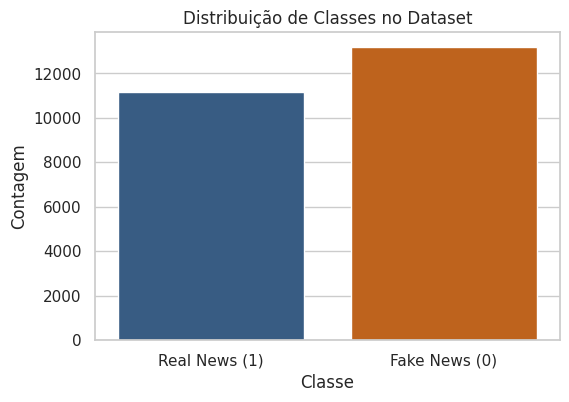

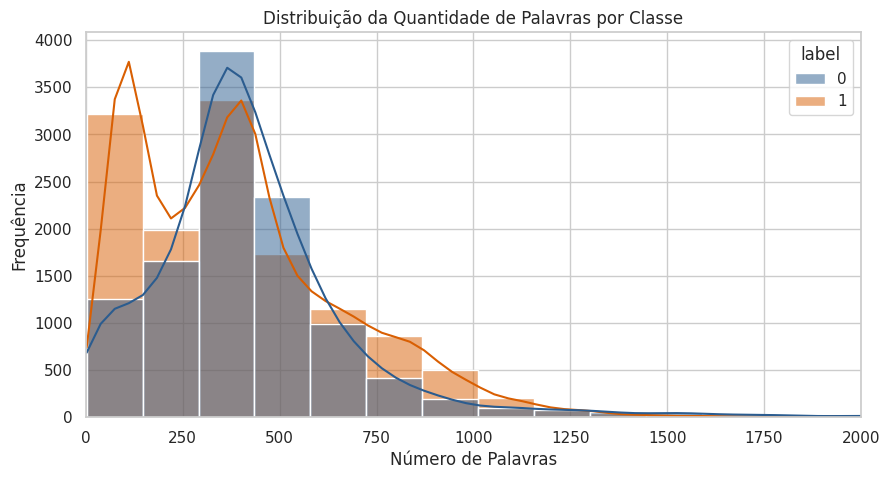

In [16]:
# ==============================================================================
# 1. ANÁLISE DE BALANCEAMENTO DE CLASSES
# Objetivo: Verificar se a quantidade de exemplos de cada classe está equilibrada
# para evitar viés no treinamento dos modelos de Machine Learning.
# ==============================================================================

# Define a largura e altura da figura em polegadas (6x4)
plt.figure(figsize=(6, 4))

# Gera um gráfico de barras que conta automaticamente as ocorrências de cada rótulo
# palette: define as cores personalizadas para cada barra (azul e laranja)
ax = sns.countplot(data=df, x='label', palette=['#2b5c8f', '#d95f02'])

# Renomeia os marcadores do eixo X para substituir '0' e '1' por nomes legíveis
ax.set_xticklabels(['Real News (1)', 'Fake News (0)'])

# Define títulos e rótulos para contextualizar o gráfico
plt.title('Distribuição de Classes no Dataset')
plt.xlabel('Classe')
plt.ylabel('Contagem')

# Exibe o gráfico na tela e limpa a memória da figura
plt.show()


# ==============================================================================
# 2. ENGENHARIA DE ATRIBUTOS E DISTRIBUIÇÃO DO TAMANHO DO TEXTO
# Objetivo: Medir a quantidade de palavras por texto e comparar o comportamento
# entre notícias reais e falsas.
# ==============================================================================

# Cria a coluna 'word_count' aplicando uma função linha por linha (apply/lambda):
# 1. str(x): garante que o dado seja tratado como string
# 2. .split(): quebra o texto pelos espaços em branco gerando uma lista de palavras
# 3. len(): conta o número total de elementos (palavras) da lista
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

# Cria uma figura mais larga (10x5) para facilitar a leitura da distribuição
plt.figure(figsize=(10, 5))

# Plota um histograma comparativo:
# - hue='label': separa e sobrepõe as distribuições de cada classe por cor
# - bins=50: divide o intervalo de contagem em 50 faixas/barras
# - kde=True (Kernel Density Estimation): desenha a curva suave de densidade estimada
sns.histplot(
    data=df,
    x='word_count',
    hue='label',
    bins=50,
    kde=True,
    palette=['#2b5c8f', '#d95f02']
)

# Customização dos eixos e título do histograma
plt.title('Distribuição da Quantidade de Palavras por Classe')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')

# Limita o eixo X entre 0 e 2000 palavras para eliminar a influência visual
# de textos atípicos/outliers muito longos e focar onde está a massa dos dados
plt.xlim(0, 2000)

# Exibe o histograma
plt.show()

In [17]:
import re
from nltk.corpus import stopwords

# ==============================================================================
# 1. PREPARAÇÃO DO CONJUNTO DE STOPWORDS
# ==============================================================================
# Carrega as stopwords em inglês e converte para estrutura 'set' (conjunto).
# A busca dentro de um 'set' em Python tem complexidade O(1), muito mais rápida que em listas.
stop_words = set(stopwords.words('english'))


# ==============================================================================
# 2. FUNÇÃO DE HIGIENIZAÇÃO E NORMALIZAÇÃO TEXTUAL
# ==============================================================================
def clean_text(text):
    # 1. Lowercasing: converte todos os caracteres para minúsculas
    text = text.lower()

    # 2. Remoção de links/URLs: detecta padrões http://, https:// e www.
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remoção de tags HTML: elimina estruturas como <br>, <p>, <div>, etc.
    text = re.sub(r'<.*?>', '', text)

    # 4. Remoção de pontuações, números e caracteres especiais:
    # Mantém estritamente letras de 'a' a 'z' (maiúsculas/minúsculas) e espaços (\s)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. Normalização de espaços: substitui múltiplos espaços/tabs/quebras por um único espaço
    # .strip() elimina espaços em branco residuais no início e no fim da string
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Tokenização simples: divide a string em uma lista de palavras pelos espaços
    tokens = text.split()

    # 7. Filtragem de termos:
    # Mantém apenas palavras que NÃO estão nas stopwords E possuem mais de 2 letras
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # 8. Reconstrução: une a lista de tokens tratados de volta em uma única string
    return ' '.join(tokens)


# ==============================================================================
# 3. AMOSTRAGEM E APLICAÇÃO DO PIPELINE
# ==============================================================================
# Cria uma amostra de 10.000 linhas para reduzir o custo computacional no ambiente.
# random_state=42: semente fixa para garantir reprodutibilidade dos resultados.
# .copy(): cria uma cópia explícita na memória para evitar warnings do pandas.
df_sample = df.sample(n=10000, random_state=42).copy()

# Aplica a função de limpeza individualmente em cada linha da coluna 'full_text'
df_sample['cleaned_text'] = df_sample['full_text'].apply(clean_text)

# Exibe as primeiras linhas do texto já tratado ao lado do rótulo correspondente
print("Exemplo de texto limpo:")
print(df_sample[['cleaned_text', 'label']].head())

Exemplo de texto limpo:
                                            cleaned_text  label
2579   tucker carlson exposes refugee contractor got ...      0
13868  romania negotiating buy rocket systems worth b...      1
13020  judge barred mom seeing baby year unpaid fees ...      0
3070   prokurdish opposition leaders trial opens turk...      1
4528   white supremacists robocall trump ahead super ...      0


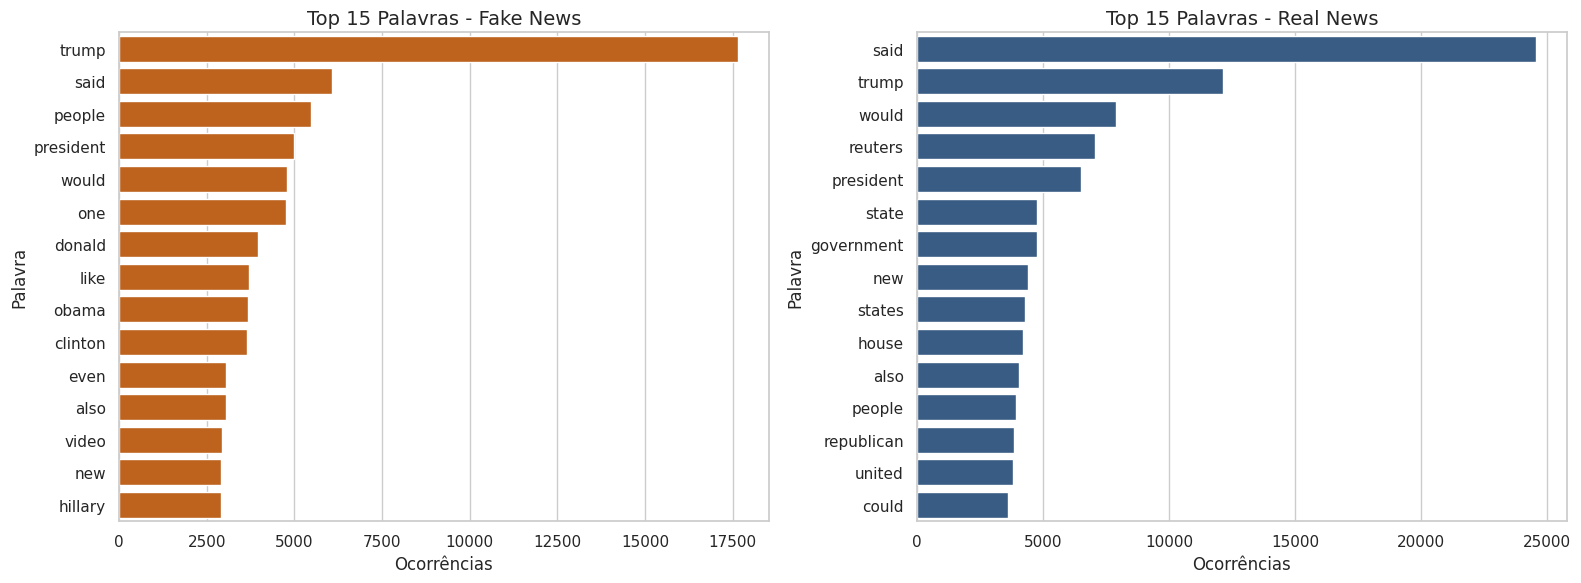

In [18]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. FUNÇÃO DE CONTAGEM E RANQUEAMENTO DE TERMOS
# ==============================================================================
def get_top_words(corpus, n=15):
    """
    Recebe uma série/lista de textos (corpus), une tudo em uma única string,
    divide em palavras e retorna as 'n' palavras mais frequentes.
    """
    # 1. ' '.join(corpus): Concatena todos os documentos em um único texto contínuo
    # 2. .split(): Quebra a grande string em uma lista de tokens individuais
    words = ' '.join(corpus).split()

    # 3. Counter(words).most_common(n): Cria uma tabela de frequência e retorna
    # as 'n' tuplas com maiores contagens no formato: [('termo', contagem), ...]
    return Counter(words).most_common(n)


# ==============================================================================
# 2. FILTRAGEM POR CLASSE E EXTRAÇÃO DOS TOP TERMOS
# ==============================================================================
# Extrai as 15 palavras mais frequentes apenas nos textos rotulados como Fake (label 0)
fake_words = get_top_words(df_sample[df_sample['label'] == 0]['cleaned_text'], n=15)

# Extrai as 15 palavras mais frequentes apenas nos textos rotulados como Real (label 1)
real_words = get_top_words(df_sample[df_sample['label'] == 1]['cleaned_text'], n=15)

# Converte as listas de tuplas em DataFrames pandas estruturados para alimentar o Seaborn
df_fake_words = pd.DataFrame(fake_words, columns=['Word', 'Count'])
df_real_words = pd.DataFrame(real_words, columns=['Word', 'Count'])


# ==============================================================================
# 3. VISUALIZAÇÃO GRÁFICA COMPARATIVA (SUBPLOTS)
# ==============================================================================
# Cria uma grade de gráficos com 1 linha e 2 colunas em uma tela de 16x6 polegadas
# axes[0] referencia o gráfico da esquerda e axes[1] o da direita
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico da esquerda (Fake News):
# - x='Count', y='Word': Gráfico de barras horizontal ordenado automaticamente pela contagem
# - color='#d95f02': Tom de laranja padronizado para representar Fake News
sns.barplot(data=df_fake_words, x='Count', y='Word', ax=axes[0], color='#d95f02')
axes[0].set_title('Top 15 Palavras - Fake News', fontsize=14)
axes[0].set_xlabel('Ocorrências', fontsize=12)
axes[0].set_ylabel('Palavra', fontsize=12)

# Gráfico da direita (Real News):
# - color='#2b5c8f': Tom de azul padronizado para representar Real News
sns.barplot(data=df_real_words, x='Count', y='Word', ax=axes[1], color='#2b5c8f')
axes[1].set_title('Top 15 Palavras - Real News', fontsize=14)
axes[1].set_xlabel('Ocorrências', fontsize=12)
axes[1].set_ylabel('Palavra', fontsize=12)

# Ajusta automaticamente o espaçamento entre os subplots para evitar sobreposição de rótulos
plt.tight_layout()

# Renderiza a figura completa
plt.show()

In [19]:
# Importa a função responsável pela divisão aleatória e controlada de matrizes/dataframes
from sklearn.model_selection import train_test_split

# 1. Separação entre variáveis preditoras (Features/X) e a variável alvo (Target/y)
# X: Dados de entrada que o modelo usará para aprender padrões (textos pré-processados)
X = df_sample['cleaned_text']

# y: Rótulos/classes esperadas que o modelo deve aprender a prever
y = df_sample['label']

# 2. Divisão dos dados em partições de Treino e Teste
# - X_train, y_train: Utilizados durante a fase de treinamento do modelo
# - X_test, y_test: Dados inéditos reservados exclusivamente para avaliação de métricas
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    # test_size=0.2 (Divisão 80/20):
    # Proporção escolhida com base na quantidade total de amostras do dataset:
    # 80% retém volume suficiente para o modelo extrair padrões complexos no treino,
    # enquanto 20% fornece uma amostragem estatisticamente confiável e representativa
    # para teste, evitando desperdício de dados de treino em bases de tamanho moderado.
    test_size=0.2,
    random_state=42,     # Semente fixa para garantir reprodutibilidade exata da divisão
    stratify=y           # Mantém a distribuição original das classes de 'y' em ambos os conjuntos
)

# 3. Exibição e verificação das dimensões resultantes
# .shape[0] extrai a quantidade de linhas (amostras) de cada subconjunto
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 8000 amostras | Teste: 2000 amostras


In [20]:
# Importa o vetorizador textual baseado no cálculo de relevância TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Importa os algoritmos de classificação supervisionada
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Importa o utilitário para encadear transformações de dados e modelos preditivos
from sklearn.pipeline import Pipeline

# -------------------------------------------------------------------------
# Pipeline 1: TF-IDF + Logistic Regression
# -------------------------------------------------------------------------
pipe_lr = Pipeline([
    # Etapa 1: Transformação de texto em matriz numérica ponderada
    ('tfidf', TfidfVectorizer(
        max_features=10000,    # Limita o vocabulário aos 10.000 termos mais frequentes para conter a dimensionalidade
        ngram_range=(1, 2)     # Considera palavras isoladas (unigramas) e pares de palavras (bigramas) para reter contexto
    )),
    # Etapa 2: Classificador linear probabilístico
    ('clf', LogisticRegression(
        random_state=42,       # Garante reprodutibilidade nos métodos numéricos de otimização
        max_iter=1000          # Aumenta o limite de iterações do solver para garantir a convergência matemática dos pesos
    ))
])

# -------------------------------------------------------------------------
# Pipeline 2: TF-IDF + Multinomial Naive Bayes (Baseline de NLP)
# -------------------------------------------------------------------------
pipe_nb = Pipeline([
    # Etapa 1: Mesma configuração de vetorização para manter a comparação justa entre os modelos
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2)
    )),
    # Etapa 2: Classificador probabilístico Bayesiano (rápido, eficiente e padrão de comparação em classificação de texto)
    ('clf', MultinomialNB())
])

# -------------------------------------------------------------------------
# Treinamento dos Modelos
# -------------------------------------------------------------------------

# Treina o Pipeline 1: ajusta o vocabulário TF-IDF em X_train e treina a Regressão Logística com y_train
print("Treinando Logistic Regression...")
pipe_lr.fit(X_train, y_train)

# Treina o Pipeline 2: ajusta o vocabulário TF-IDF em X_train e treina o Naive Bayes com y_train
print("Treinando Naive Bayes...")
pipe_nb.fit(X_train, y_train)

# Sinalização de conclusão do processo de ajuste
print("Modelos treinados com sucesso!")

Treinando Logistic Regression...
Treinando Naive Bayes...
Modelos treinados com sucesso!


In [21]:
# Importa ferramentas para avaliação quantitativa de modelos de classificação supervisionada
from sklearn.metrics import (
    classification_report,  # Gera tabela detalhada com Precision, Recall, F1-Score e Support
    confusion_matrix,       # Importado para montagem/análise da matriz de erros e acertos (FP, FN, TP, TN)
    accuracy_score,         # Importado para cálculo direto da taxa global de acerto
    f1_score                # Importado para cálculo isolado do F1-score
)

# -------------------------------------------------------------------------
# 1. Inferência / Geração de Predições
# -------------------------------------------------------------------------

# O pipeline transforma X_test via TF-IDF (usando o vocabulário do treino) e infere as classes com a Regressão Logística
y_pred_lr = pipe_lr.predict(X_test)

# Executa o mesmo processo de vetorização e predição utilizando o classificador Naive Bayes
y_pred_nb = pipe_nb.predict(X_test)

# -------------------------------------------------------------------------
# 2. Configuração de Rótulos e Exibição dos Relatórios
# -------------------------------------------------------------------------

# Nomes das classes para mapear os índices binários [0, 1] em rótulos compreensíveis no relatório
target_names = ['Fake News (0)', 'Real News (1)']

# Avaliação detalhada do modelo de Regressão Logística
print("=== RELATÓRIO: LOGISTIC REGRESSION ===")
print(classification_report(
    y_test,          # Valores reais esperados (gabarito)
    y_pred_lr,       # Valores previstos pelo modelo de Regressão Logística
    target_names=target_names
))

# Avaliação detalhada do modelo Naive Bayes
print("\n=== RELATÓRIO: MULTINOMIAL NAIVE BAYES ===")
print(classification_report(
    y_test,          # Valores reais esperados (gabarito)
    y_pred_nb,       # Valores previstos pelo modelo Naive Bayes
    target_names=target_names
))

=== RELATÓRIO: LOGISTIC REGRESSION ===
               precision    recall  f1-score   support

Fake News (0)       0.96      0.96      0.96       912
Real News (1)       0.97      0.96      0.97      1088

     accuracy                           0.96      2000
    macro avg       0.96      0.96      0.96      2000
 weighted avg       0.96      0.96      0.96      2000


=== RELATÓRIO: MULTINOMIAL NAIVE BAYES ===
               precision    recall  f1-score   support

Fake News (0)       0.92      0.92      0.92       912
Real News (1)       0.94      0.93      0.93      1088

     accuracy                           0.93      2000
    macro avg       0.93      0.93      0.93      2000
 weighted avg       0.93      0.93      0.93      2000



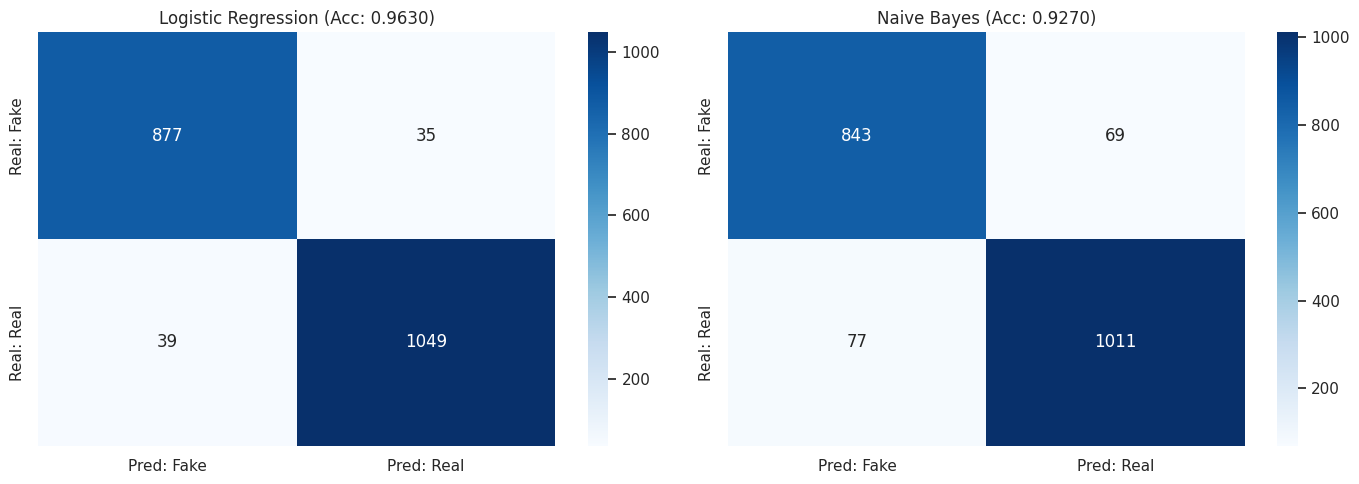

In [22]:
# Cria a área de plotagem: 1 linha e 2 colunas para comparação lado a lado (14 polegadas de largura x 5 de altura)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------------------------------------------------
# 1. Matriz de Confusão: Logistic Regression
# -------------------------------------------------------------------------

# Gera a matriz 2x2 cruzando as classes reais (y_test) com as previstas (y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plota o mapa de calor no primeiro subplot (posição axes[0])
sns.heatmap(
    cm_lr,
    annot=True,                                   # Exibe a quantidade de amostras em cada célula
    fmt='d',                                      # Garante que os números apareçam como inteiros formatados
    cmap='Blues',                                 # Paleta de cores em escala de azul (tons mais escuros = mais amostras)
    ax=axes[0],                                   # Define o posicionamento no primeiro painel (lado esquerdo)
    xticklabels=['Pred: Fake', 'Pred: Real'],     # Rótulos do eixo X (o que o modelo previu)
    yticklabels=['Real: Fake', 'Real: Real']      # Rótulos do eixo Y (a classe real/gabarito)
)
# Define o título do painel esquerdo incluindo o cálculo dinâmico da acurácia com 4 casas decimais
axes[0].set_title(f'Logistic Regression (Acc: {accuracy_score(y_test, y_pred_lr):.4f})')

# -------------------------------------------------------------------------
# 2. Matriz de Confusão: Naive Bayes
# -------------------------------------------------------------------------

# Gera a matriz 2x2 para as predições do Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plota o mapa de calor no segundo subplot (posição axes[1])
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],                                   # Define o posicionamento no segundo painel (lado direito)
    xticklabels=['Pred: Fake', 'Pred: Real'],
    yticklabels=['Real: Fake', 'Real: Real']
)
# Define o título do painel direito com a acurácia calculada do Naive Bayes
axes[1].set_title(f'Naive Bayes (Acc: {accuracy_score(y_test, y_pred_nb):.4f})')

# -------------------------------------------------------------------------
# 3. Finalização e Renderização Gráfica
# -------------------------------------------------------------------------

# Ajusta automaticamente o espaçamento para evitar corte de rótulos ou sobreposição de títulos
plt.tight_layout()

# Renderiza e exibe a visualização gráfica
plt.show()

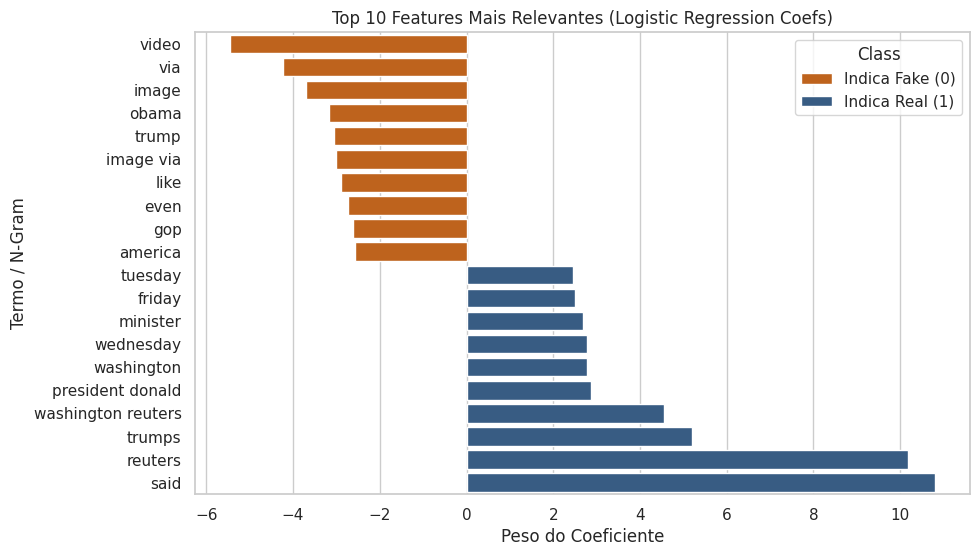

In [23]:
# -------------------------------------------------------------------------
# 1. Extração dos Componentes e Parâmetros Internos do Pipeline
# -------------------------------------------------------------------------

# Acessa individualmente a etapa de vetorização TF-IDF já ajustada aos dados
vectorizer = pipe_lr.named_steps['tfidf']

# Acessa o modelo de Regressão Logística treinado
model = pipe_lr.named_steps['clf']

# Obtém a lista com todas as 10.000 palavras/n-gramas presentes no vocabulário
feature_names = np.array(vectorizer.get_feature_names_out())

# Extrai o array de coeficientes (pesos numéricos associados a cada feature)
# Em classificação binária, o Scikit-Learn armazena os pesos em uma matriz 1xN (coef_[0])
coefficients = model.coef_[0]

# -------------------------------------------------------------------------
# 2. Seleção dos Termos Mais Influentes para Cada Classe
# -------------------------------------------------------------------------

# np.argsort ordena os índices em ordem crescente de valor:
# - [-10:]: Pega os 10 maiores coeficientes positivos (maior impacto em favor da Classe 1 / Real)
top_real_idx = np.argsort(coefficients)[-10:]

# - [:10]: Pega os 10 menores coeficientes/mais negativos (maior impacto em favor da Classe 0 / Fake)
top_fake_idx = np.argsort(coefficients)[:10]

# -------------------------------------------------------------------------
# 3. Estruturação dos Dados para Visualização
# -------------------------------------------------------------------------

# Concatena os índices selecionados em um DataFrame do Pandas
top_features = pd.DataFrame({
    # Nomes dos 10 termos mais associados a Fake News seguidos dos 10 termos de Real News
    'Feature': np.concatenate([feature_names[top_fake_idx], feature_names[top_real_idx]]),

    # Pesos numéricos exatos correspondentes a cada um desses termos
    'Importance': np.concatenate([coefficients[top_fake_idx], coefficients[top_real_idx]]),

    # Rótulo de classificação correspondente para colorir e agrupar o gráfico
    'Class': ['Indica Fake (0)'] * 10 + ['Indica Real (1)'] * 10
})

# -------------------------------------------------------------------------
# 4. Geração do Gráfico de Importância de Features
# -------------------------------------------------------------------------

# Cria a figura com proporção de 10x6 polegadas
plt.figure(figsize=(10, 6))

# Plota as barras horizontais: o comprimento representa o peso e a cor representa a classe
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    hue='Class',
    palette=['#d95f02', '#2b5c8f']  # Laranja/Marrom para Fake News e Azul para Real News
)

# Configuração de títulos e legendas dos eixos
plt.title('Top 10 Features Mais Relevantes (Logistic Regression Coefs)')
plt.xlabel('Peso do Coeficiente')
plt.ylabel('Termo / N-Gram')

# Exibe o gráfico final
plt.show()

In [24]:
# Importa o utilitário de alto nível da Hugging Face para tarefas de NLP com modelos pré-treinados
from transformers import pipeline

# Importa a biblioteca padrão de medição de tempo para avaliar latência/custo computacional
import time

# Importa ferramentas de métricas do Scikit-Learn para comparar com o gabarito
from sklearn.metrics import classification_report, accuracy_score

# -------------------------------------------------------------------------
# 1. Carregamento do Modelo Pré-treinado (Zero-Shot NLI)
# -------------------------------------------------------------------------

# Inicializa o pipeline de classificação zero-shot:
# O modelo BART-large treinado em MNLI compara a notícia com hipóteses semânticas
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1  # -1 executa na CPU; altere para 0 caso utilize ambiente com GPU (ex: Google Colab)
)

# -------------------------------------------------------------------------
# 2. Definição da Amostra de Teste e Configuração dos Rótulos
# -------------------------------------------------------------------------

# Seleciona 50 amostras do conjunto de teste para avaliação de latência e viabilidade computacional
test_sample = X_test.iloc[:50]
y_true_sample = y_test.iloc[:50]

# Rótulos descritivos passados ao modelo (a riqueza semântica melhora a inferência de NLI)
candidate_labels = ["fake news or misinformation", "real factual news"]

# Dicionário de-para: converte a string prevista de volta para os identificadores numéricos do dataset
label_map = {
    "fake news or misinformation": 0,
    "real factual news": 1
}

# -------------------------------------------------------------------------
# 3. Execução da Inferência com Medição de Tempo
# -------------------------------------------------------------------------

# Marca o instante inicial do processamento
start_time = time.time()
llm_preds = []

print("Executando inferência Zero-Shot...")
for text in test_sample:
    # text[:512]: Trunca o texto nos primeiros 512 caracteres para acelerar a computação dos mecanismos de atenção
    res = classifier(text[:512], candidate_labels)

    # A Hugging Face retorna os rótulos ordenados por probabilidade; o índice 0 é a predição mais provável
    predicted_label = res['labels'][0]

    # Mapeia a string para 0 ou 1 e adiciona à lista de predições
    llm_preds.append(label_map[predicted_label])

# Calcula o tempo total gasto na inferência das 50 amostras
llm_elapsed_time = time.time() - start_time
print(f"Inferência concluída em {llm_elapsed_time:.2f} segundos.")

# -------------------------------------------------------------------------
# 4. Avaliação de Desempenho
# -------------------------------------------------------------------------

# Gera o relatório com Precision, Recall e F1-score comparando as predições do BART com y_true_sample
print("\n=== RELATÓRIO: ZERO-SHOT LLM (BART-MNLI) ===")
print(classification_report(
    y_true_sample,
    llm_preds,
    target_names=['Fake News (0)', 'Real News (1)']
))

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Executando inferência Zero-Shot...
Inferência concluída em 186.79 segundos.

=== RELATÓRIO: ZERO-SHOT LLM (BART-MNLI) ===
               precision    recall  f1-score   support

Fake News (0)       0.92      0.38      0.54        29
Real News (1)       0.53      0.95      0.68        21

     accuracy                           0.62        50
    macro avg       0.72      0.67      0.61        50
 weighted avg       0.75      0.62      0.60        50



In [25]:
# -------------------------------------------------------------------------
# 1. Medição de Latência / Tempo de Inferência da Regressão Logística
# -------------------------------------------------------------------------

# Registra o timestamp inicial
start_time = time.time()

# Executa a predição na mesma amostra de 50 textos usada na LLM
# O uso de '_' descarta a variável de retorno, focando apenas em medir a latência
_ = pipe_lr.predict(test_sample)

# Calcula o tempo total decorrido para inferência com o modelo linear + TF-IDF
lr_elapsed_time = time.time() - start_time

# -------------------------------------------------------------------------
# 2. Consolidação do Benchmark em um DataFrame Comparativo
# -------------------------------------------------------------------------

comparison_df = pd.DataFrame({
    # Nome das duas arquiteturas avaliadas
    'Abordagem': [
        'Regressão Logística (TF-IDF)',
        'Zero-Shot LLM (BART-MNLI)'
    ],

    # Diferença metodológica fundamental no ciclo de vida de cada modelo
    'Paradigma': [
        'Supervisionado (Requer treino)',  # Exige dados rotulados e etapa prévia de fit()
        'Pré-treinado (Zero-Shot)'         # Classifica diretamente a partir da semântica prévia
    ],

    # Comparação de acurácia global na mesma fatia de 50 exemplos de teste
    'Acurácia (Amostra)': [
        accuracy_score(y_true_sample, pipe_lr.predict(test_sample)),
        accuracy_score(y_true_sample, llm_preds)
    ],

    # Contraste de latência por lote de inferência (convertido para ms na abordagem rápida)
    'Tempo de Inferência (50 docs)': [
        f"{lr_elapsed_time * 1000:.2f} ms",  # Modelos lineares respondem na ordem de milissegundos
        f"{llm_elapsed_time:.2f} s"          # Transformers em CPU levam ordens de grandeza a mais (segundos)
    ],

    # Requisitos de infraestrutura e hardware para produção
    'Custo Computacional': [
        'Muito Baixo (CPU)',      # Consumo mínimo de memória RAM e processamento
        'Alto (Idealmente GPU)'   # Demanda alta taxa de operações de matriz e memória VRAM
    ]
})

# Exibe a tabela consolidada de resultados
comparison_df

,Abordagem,Paradigma,Acurácia (Amostra),Tempo de Inferência (50 docs),Custo Computacional
0,Regressão Logística (TF-IDF),Supervisionado (Requer treino),0.96,31.28 ms,Muito Baixo (CPU)
1,Zero-Shot LLM (BART-MNLI),Pré-treinado (Zero-Shot),0.62,186.79 s,Alto (Idealmente GPU)
